In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/household_power_consumption.txt",
    sep=";",
    low_memory=False)
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB


In [5]:
# 1. Vérifier la présence de "?" dans les colonnes concernées
colonnes_numeriques = [
    "Global_active_power", "Global_reactive_power",
    "Voltage", "Global_intensity",
    "Sub_metering_1", "Sub_metering_2"
]

for col in colonnes_numeriques:
    print(col, "->", (df[col] == "?").sum(), "valeurs '?'")

Global_active_power -> 25979 valeurs '?'
Global_reactive_power -> 25979 valeurs '?'
Voltage -> 25979 valeurs '?'
Global_intensity -> 25979 valeurs '?'
Sub_metering_1 -> 25979 valeurs '?'
Sub_metering_2 -> 25979 valeurs '?'


In [6]:
# 2. Convertir en numérique, en remplaçant les "?" par NaN automatiquement
for col in colonnes_numeriques:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

print("""
Explication du errors="coerce" : ça dit à pandas "convertis tout ce qui ressemble à un nombre ; 
ce qui ne l'est pas (comme "?"), transforme-le en NaN au lieu de planter". 
C'est la bonne pratique ici plutôt qu'un remplacement manuel un par un.
""")

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB

Explication du errors="coerce" : ça dit à pandas "convertis tout ce qui ressemble à un nombre ; 
ce qui ne l'est pas (comme "?"), transforme-le en NaN au lieu de planter". 
C'est la bonne pratique ici plutôt qu'un remplacement manuel un par un.



In [7]:
df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
df = df.drop(columns=["Date", "Time"])
df = df.set_index("timestamp")
df.head()

# print("""Pourquoi préciser format= : sans ça, pandas doit deviner le format à chaque 
#     ligne (lent sur 2 millions de lignes, et parfois ambigu entre jour/mois). 
#     Lui donner le format explicite (%d/%m/%Y, car ce dataset est au format 
#     européen jour/mois/année) est plus rapide et plus fiable.")
# """

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [9]:
df.index.to_series().diff().value_counts().head()
# Ça confirme si les mesures sont bien espacées d'exactement 1 minute partout, 
# ou s'il y a des trous (pannes de collecte).

timestamp
0 days 00:01:00    2075258
Name: count, dtype: int64

In [10]:
df.isna().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [11]:
print("""
1. Le taux de valeurs manquantes est faible, mais la méthode de traitement compte

25 979 / 2 075 259 ≈ 1,25% de valeurs manquantes. C'est peu, mais pour 
une série temporelle, supprimer ces lignes serait une erreur : 
ça créerait des trous dans le temps (des minutes qui disparaissent), 
ce qui fausse ensuite tout rééchantillonnage ou calcul de moyenne mobile. 
La bonne pratique ici est l'interpolation temporelle (on comble le trou 
en se basant sur les valeurs juste avant/après), pas la suppression. 
On fera ça une fois le timestamp en place.
""")

# Interpolation des valeurs manquantes (basée sur le temps, pas juste la position)
df = df.interpolate(method="time")


1. Le taux de valeurs manquantes est faible, mais la méthode de traitement compte

25 979 / 2 075 259 ≈ 1,25% de valeurs manquantes. C'est peu, mais pour 
une série temporelle, supprimer ces lignes serait une erreur : 
ça créerait des trous dans le temps (des minutes qui disparaissent), 
ce qui fausse ensuite tout rééchantillonnage ou calcul de moyenne mobile. 
La bonne pratique ici est l'interpolation temporelle (on comble le trou 
en se basant sur les valeurs juste avant/après), pas la suppression. 
On fera ça une fois le timestamp en place.



In [12]:
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [14]:
df.index.to_series().diff().value_counts().head()

timestamp
0 days 00:01:00    2075258
Name: count, dtype: int64

In [15]:
df_horaire = df.resample("h").mean()
df_horaire.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [16]:
df_horaire.to_csv("../data/conso_horaire_propre.csv")

In [17]:
df_horaire.shape

(34589, 7)

In [18]:
# On ne garde que la colonne qui nous intéresse pour le projet
conso = df_horaire["Global_active_power"].copy()

# Ajouter des colonnes utiles pour l'analyse par profil
conso_df = conso.to_frame(name="conso_kw")
conso_df["heure"] = conso_df.index.hour
conso_df["jour_semaine"] = conso_df.index.dayofweek  # 0 = lundi, 6 = dimanche

# Profil moyen par heure de la journée
profil_horaire = conso_df.groupby("heure")["conso_kw"].mean()
print(profil_horaire)

# Profil moyen par jour de la semaine
profil_hebdo = conso_df.groupby("jour_semaine")["conso_kw"].mean()
print(profil_hebdo)

heure
0     0.663418
1     0.544698
2     0.486809
3     0.451589
4     0.450522
5     0.460220
6     0.793647
7     1.494386
8     1.453509
9     1.326026
10    1.256255
11    1.242120
12    1.203516
13    1.141929
14    1.081551
15    0.991351
16    0.950159
17    1.056336
18    1.322805
19    1.724749
20    1.889776
21    1.867966
22    1.408790
23    0.903677
Name: conso_kw, dtype: float64
jour_semaine
0    1.001749
1    1.074770
2    1.085026
3    0.982072
4    1.042066
5    1.233893
6    1.213079
Name: conso_kw, dtype: float64


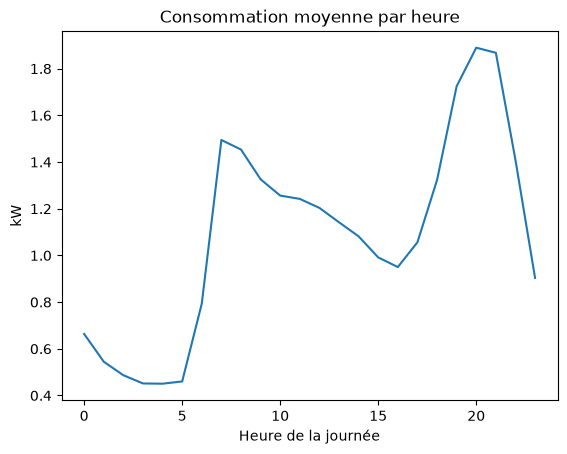

In [19]:
import matplotlib.pyplot as plt

profil_horaire.plot(kind="line", title="Consommation moyenne par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("kW")
plt.show()

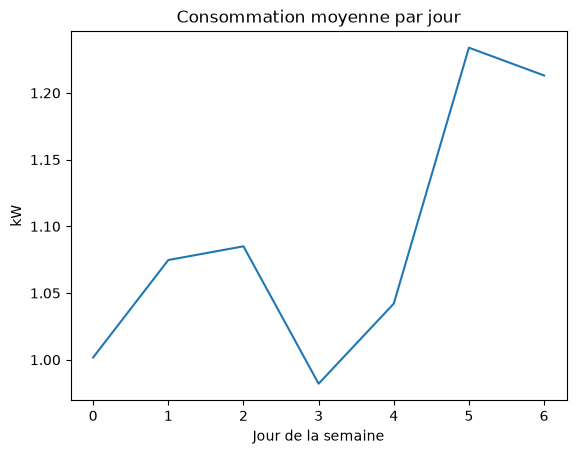

In [20]:
profil_hebdo.plot(kind="line", title="Consommation moyenne par jour")
plt.xlabel("Jour de la semaine")
plt.ylabel("kW")
plt.show()

In [21]:
df_anomalie = pd.read_csv("../data/anomalies_verite_terrain.csv", low_memory=False)
df_anomalie.head()

,site_id,timestamp,type,valeur_originale,valeur_injectee
0,1,2024-06-30 07:00:00,coupure,3.057,0.055
1,1,2024-01-20 02:00:00,coupure,0.983,0.018
2,1,2024-06-15 17:00:00,coupure,2.189,0.069
3,1,2024-06-13 23:00:00,pic,1.507,5.686
4,1,2024-04-15 19:00:00,coupure,2.915,0.235


In [25]:
df_anomalie = df_anomalie.sort_values("timestamp")

In [26]:
df_anomalie.to_csv("../data/anomalies_verite_terrain.csv", index=False)